/Users/tanghy/opt/anaconda3/lib/python3.8/site-packages/scipy/integrate/_ivp/common.py:337: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
/Users/tanghy/opt/anaconda3/lib/python3.8/site-packages/scipy/integrate/_ivp/common.py:306: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
/Users/tanghy/opt/anaconda3/lib/python3.8/site-packages/scipy/integrate/_ivp/common.py:336: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/Users/tanghy/opt/anaconda3/lib/python3.8/site-packages/scipy/integrate/_ivp/common.py:358: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


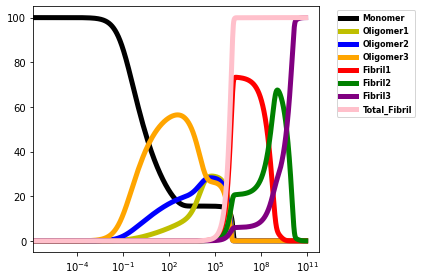

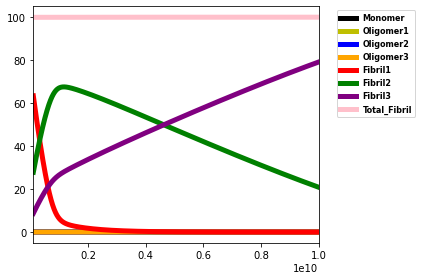

In [2]:
###### Extension of two-pathway to three-pathway in our multi-pathway model 

###### Figure 4A,B

###### We normalized rate-mass equations by fibril1 stability (phi_CR1) and oligomer1-monomer dissociation rate

import matplotlib.pyplot as plt
import numpy as np
import math
import matplotlib.cm as cm
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker
plt.close('all')

switch=0
global switch
for nf3 in [6]:                # Tune the parameter of interest
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf1, 5Nf2, 6Nf3, 7Phi_CR1, 8Phi_CR2, 9Phi_CR3, 10Kf1-p;1st-pathway, 11Kf1-;1st-pathway, 12Kf2-p;2nd-pathway,
    #      13Kf2-;2nd-pathway, 14Kf3-p;3rd-pathway, 15Kf3-;3rd-pathway, 16Kfrag, 17G1, 18G2, 19G3]
    p0=   [0,     0,    0,       0, 4, 5, nf3, 0.1, 0.03, 0.01, 10**(-4), 5*10**(-7), 10**(-4), 15*10**(-8), 10**(-4), 5*10**(-8), 0, 6, 7, 8 ]      # Free parameters in our model
    yyy=[0.6,0.8,1,2,4,8,10,20,31,40,50,60,70,80,90,100,200,300,400,500]                                                                             # Discrete point initial peptide concentrations
    yy = [x / p0[7] for x in yyy]                                                                                                                    # Normalized Discrete point initial peptide concentrations
    n= len(yyy)                                                                                                                                      # Total discrete point concentration
    phi_su1=p0[10]*p0[7]/p0[11]
    phi_su2=p0[12]*p0[8]/p0[13]
    phi_su3=p0[14]*p0[9]/p0[15]

    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u):
        global switch
        du = [0]*64         # Introduce all states in our model
        
        #### Some aaproximation
        CC1=0;CC2=0;CC3=0;FF1=0;FF2=0;FF3=0
        for i in range (10,27):
            CC1 += u[i]
            FF1 += (p[4]+ (i-9))*u[i]
        for i in range (27,44):
            CC2 += u[i]
            FF2 += (p[5]+ (i-26))*u[i]
        for i in range (47,64):
            CC3 += u[i]
            FF3 += (p[6]+ (i-46))*u[i]

        #### Aproximate nf1+9 and truncate the high order dependency
        if t>0:
            if u[25]<= 0:
                n1plus1= 0
            else:
                if u[0]>= 1:
                    n1plus1= u[26]*u[26]/u[25]
                else :
                    CC4= u[5] -  CC1                   
                    FF4= u[6] -  FF1                   
                    if CC4 <= 0 or FF4 < 0  or FF4/CC4 <= p[4]+ 17:
                        n1plus1=0
                        switch=1
                    else:
                        n1plus1= CC4/((FF4/CC4-(p[4]+17)))
        else:
            n1plus1= 0
        #### Aproximate nf2+9 and truncate the high order dependency
        if t>0:
            if u[42]<= 0:
                n2plus1= 0
            else:
                if u[0]>= p[8]/p[7]:
                    n2plus1= u[43]*u[43]/u[42]
                else:
                    CC5= u[8] -  CC2        #u[35]/(1-sigma)
                    FF5= u[9] -  FF2        #u[35]* (p[5]+1-p[5]*sigma)/(1-sigma)**2
                    if CC5 <=0 or FF5 <= 0 or FF5/CC5 <= p[5]+17:
                        n2plus1=0
                        switch=1
                    else:
                        n2plus1= CC5/((FF5/CC5 -(p[5]+17)))
        else:
            n2plus1= 0
        #### Aproximate nf3+9 and truncate the high order dependency
        if t>0:
            if u[62] <= 0:
                n3plus1= 0
            else:
                if u[0]>= p[9]/p[7]:
                    n3plus1= u[63]*u[63]/u[62]
                else:
                    CC6 = u[45] -  CC3
                    FF6 = u[46] -  FF3
                    if CC6 <=0 or FF6 <= 0 or FF6/CC6 <= p[6]+17:
                        n3plus1=0
                    else:
                        n3plus1= CC6/((FF6/CC6 -(p[6]+17)))
        else:
            n3plus1= 0

        ### Define different terms
        EEE1= (p[7]/phi_su1)**(p[4]-1)*u[0]**p[4] - u[4];                                # 1st-pathway oligomer number nucleation
        EEE2= p[12]/p[10]*((p[7]/phi_su2)**(p[5]-1)*u[0]**p[5] - u[7]);                  # 2nd-pathway oligomer number nucleation
        EEE3= p[14]/p[10]*((p[7]/phi_su3)**(p[6]-1)*u[0]**p[6] - u[44]);                 # 3rd-pathway oligomer number nucleation
        EE1=  p[4]*EEE1;                                                                 # 1st-pathway oligomer mass nucleation
        EE2=  p[5]*EEE2;                                                                 # 2nd-pathway oligomer mass nucleation
        EE3=  p[6]*EEE3;                                                                 # 3rd-pathway oligomer mass nucleation
        NNN1= (p[7]/phi_su1)*(u[0]*u[4] - u[10])*np.exp(-p[17])                          # 1st-pathway oligomer to fibril seed conversion
        NNN2= p[12]/p[10]*(p[7]/phi_su2)*(u[0]*u[7] - u[27]*p[8]/p[7])*np.exp(-p[18])    # 2nd-pathway oligomer to fibril seedconversion
        NNN3= p[14]/p[10]*(p[7]/phi_su3)*(u[0]*u[44] - u[47]*p[9]/p[7])*np.exp(-p[19])   # 3rd-pathway oligomer to fibril seed conversion
        NN1= (p[4]+1)* NNN1                                                              # fibril mass from 1st-pathway oligomer to fibril seed conversion
        NN2= (p[5]+1)* NNN2                                                              # fibril mass from 2nd-pathway oligomer to fibril seed conversion
        NN3= (p[6]+1)* NNN3                                                              # fibril mass from 3st-pathway oligomer to fibril seed conversion
        GG1= (u[0]-1)*u[5]*(p[7]/phi_su1) +  (p[7]/phi_su1)* u[10];                      # Growth and shrinking of the 1st-pathway fibril
        GG2= p[12]/p[10]*((u[0]-p[8]/p[7])*u[8]*(p[7]/phi_su2) + (p[8]/phi_su2)* u[27]); # Growth and shrinking of the 2nd-pathway fibril
        GG3= p[14]/p[10]*((u[0]-p[9]/p[7])*u[45]*(p[7]/phi_su3) + (p[9]/phi_su3)* u[47]) # Growth and shrinking of the 2nd-pathway fibril


        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2 - EE3  - GG3 - NNN3
        du[1] = 0
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 
        du[6] = NN1 + GG1
        du[7] = EEE2 - NNN2
        du[8] = NNN2 
        du[9] = NN2 + GG2
        ##########################################################
        du[10]= (u[0]*u[4]*np.exp(-p[17]) -(u[0] + np.exp(-p[17]))*u[10] + u[11])*p[7]/phi_su1
        du[11]= (u[0]*u[10] -(u[0] + 1)*u[11] + u[12])*p[7]/phi_su1
        du[12]= (u[0]*u[11] -(u[0] + 1)*u[12] + u[13])*p[7]/phi_su1
        du[13]= (u[0]*u[12] -(u[0] + 1)*u[13] + u[14])*p[7]/phi_su1
        du[14]= (u[0]*u[13] -(u[0] + 1)*u[14] + u[15])*p[7]/phi_su1
        du[15]= (u[0]*u[14] -(u[0] + 1)*u[15] + u[16])*p[7]/phi_su1
        du[16]= (u[0]*u[15] -(u[0] + 1)*u[16] + u[17])*p[7]/phi_su1
        du[17]= (u[0]*u[16] -(u[0] + 1)*u[17] + u[18])*p[7]/phi_su1
        du[18]= (u[0]*u[17] -(u[0] + 1)*u[18] + u[19])*p[7]/phi_su1
        du[19]= (u[0]*u[18] -(u[0] + 1)*u[19] + u[20])*p[7]/phi_su1
        du[20]= (u[0]*u[19] -(u[0] + 1)*u[20] + u[21])*p[7]/phi_su1
        du[21]= (u[0]*u[20] -(u[0] + 1)*u[21] + u[22])*p[7]/phi_su1
        du[22]= (u[0]*u[21] -(u[0] + 1)*u[22] + u[23])*p[7]/phi_su1
        du[23]= (u[0]*u[22] -(u[0] + 1)*u[23] + u[24])*p[7]/phi_su1
        du[24]= (u[0]*u[23] -(u[0] + 1)*u[24] + u[25])*p[7]/phi_su1
        du[25]= (u[0]*u[24] -(u[0] + 1)*u[25] + u[26])*p[7]/phi_su1
        du[26]= (u[0]*u[25] -(u[0] + 1)*u[26] + n1plus1)*p[7]/phi_su1

        ###########################################################
        du[27]= p[12]/p[10]*(u[0]*u[7]*np.exp(-p[18]) -(u[0] + p[8]/p[7]*np.exp(-p[18]))*u[27] + p[8]/p[7]*u[28])*p[7]/phi_su2
        du[28]= p[12]/p[10]*(u[0]*u[27] -(u[0] + p[8]/p[7])*u[28] + p[8]/p[7]*u[29])*p[7]/phi_su2
        du[29]= p[12]/p[10]*(u[0]*u[28] -(u[0] + p[8]/p[7])*u[29] + p[8]/p[7]*u[30])*p[7]/phi_su2
        du[30]= p[12]/p[10]*(u[0]*u[29] -(u[0] + p[8]/p[7])*u[30] + p[8]/p[7]*u[31])*p[7]/phi_su2
        du[31]= p[12]/p[10]*(u[0]*u[30] -(u[0] + p[8]/p[7])*u[31] + p[8]/p[7]*u[32])*p[7]/phi_su2
        du[32]= p[12]/p[10]*(u[0]*u[31] -(u[0] + p[8]/p[7])*u[32] + p[8]/p[7]*u[33])*p[7]/phi_su2
        du[33]= p[12]/p[10]*(u[0]*u[32] -(u[0] + p[8]/p[7])*u[33] + p[8]/p[7]*u[34])*p[7]/phi_su2
        du[34]= p[12]/p[10]*(u[0]*u[33] -(u[0] + p[8]/p[7])*u[34] + p[8]/p[7]*u[35])*p[7]/phi_su2
        du[35]= p[12]/p[10]*(u[0]*u[34] -(u[0] + p[8]/p[7])*u[35] + p[8]/p[7]*u[36])*p[7]/phi_su2
        du[36]= p[12]/p[10]*(u[0]*u[35] -(u[0] + p[8]/p[7])*u[36] + p[8]/p[7]*u[37])*p[7]/phi_su2
        du[37]= p[12]/p[10]*(u[0]*u[36] -(u[0] + p[8]/p[7])*u[37] + p[8]/p[7]*u[38])*p[7]/phi_su2
        du[38]= p[12]/p[10]*(u[0]*u[37] -(u[0] + p[8]/p[7])*u[38] + p[8]/p[7]*u[39])*p[7]/phi_su2
        du[39]= p[12]/p[10]*(u[0]*u[38] -(u[0] + p[8]/p[7])*u[39] + p[8]/p[7]*u[40])*p[7]/phi_su2
        du[40]= p[12]/p[10]*(u[0]*u[39] -(u[0] + p[8]/p[7])*u[40] + p[8]/p[7]*u[41])*p[7]/phi_su2
        du[41]= p[12]/p[10]*(u[0]*u[40] -(u[0] + p[8]/p[7])*u[41] + p[8]/p[7]*u[42])*p[7]/phi_su2
        du[42]= p[12]/p[10]*(u[0]*u[41] -(u[0] + p[8]/p[7])*u[42] + p[8]/p[7]*u[43])*p[7]/phi_su2
        du[43]= p[12]/p[10]*(u[0]*u[42] -(u[0] + p[8]/p[7])*u[43] + p[8]/p[7]*n2plus1)*p[7]/phi_su2
        
        ############################################################
        du[44]= EEE3 - NNN3
        du[45]= NNN3 
        du[46]= NN3 + GG3
        du[47]= p[14]/p[10]*(u[0]*u[44]*np.exp(-p[19]) -(u[0] + p[9]/p[7]*np.exp(-p[19]))*u[47] + p[9]/p[7]*u[48])*p[7]/phi_su3
        du[48]= p[14]/p[10]*(u[0]*u[47] -(u[0] + p[9]/p[7])*u[48] + p[9]/p[7]*u[49])*p[7]/phi_su3
        du[49]= p[14]/p[10]*(u[0]*u[48] -(u[0] + p[9]/p[7])*u[49] + p[9]/p[7]*u[50])*p[7]/phi_su3
        du[50]= p[14]/p[10]*(u[0]*u[49] -(u[0] + p[9]/p[7])*u[50] + p[9]/p[7]*u[51])*p[7]/phi_su3
        du[51]= p[14]/p[10]*(u[0]*u[50] -(u[0] + p[9]/p[7])*u[51] + p[9]/p[7]*u[52])*p[7]/phi_su3
        du[52]= p[14]/p[10]*(u[0]*u[51] -(u[0] + p[9]/p[7])*u[52] + p[9]/p[7]*u[53])*p[7]/phi_su3
        du[53]= p[14]/p[10]*(u[0]*u[52] -(u[0] + p[9]/p[7])*u[53] + p[9]/p[7]*u[54])*p[7]/phi_su3
        du[54]= p[14]/p[10]*(u[0]*u[53] -(u[0] + p[9]/p[7])*u[54] + p[9]/p[7]*u[55])*p[7]/phi_su3
        du[55]= p[14]/p[10]*(u[0]*u[54] -(u[0] + p[9]/p[7])*u[55] + p[9]/p[7]*u[56])*p[7]/phi_su3
        du[56]= p[14]/p[10]*(u[0]*u[55] -(u[0] + p[9]/p[7])*u[56] + p[9]/p[7]*u[57])*p[7]/phi_su3
        du[57]= p[14]/p[10]*(u[0]*u[56] -(u[0] + p[9]/p[7])*u[57] + p[9]/p[7]*u[58])*p[7]/phi_su3
        du[58]= p[14]/p[10]*(u[0]*u[57] -(u[0] + p[9]/p[7])*u[58] + p[9]/p[7]*u[59])*p[7]/phi_su3
        du[59]= p[14]/p[10]*(u[0]*u[58] -(u[0] + p[9]/p[7])*u[59] + p[9]/p[7]*u[60])*p[7]/phi_su3
        du[60]= p[14]/p[10]*(u[0]*u[59] -(u[0] + p[9]/p[7])*u[60] + p[9]/p[7]*u[61])*p[7]/phi_su3
        du[61]= p[14]/p[10]*(u[0]*u[60] -(u[0] + p[9]/p[7])*u[61] + p[9]/p[7]*u[62])*p[7]/phi_su3
        du[62]= p[14]/p[10]*(u[0]*u[61] -(u[0] + p[9]/p[7])*u[62] + p[9]/p[7]*u[63])*p[7]/phi_su3
        du[63]= p[14]/p[10]*(u[0]*u[62] -(u[0] + p[9]/p[7])*u[63] + p[9]/p[7]*n3plus1)*p[7]/phi_su3

        if switch == 1 and u[0]< p[8]:
            CC7= u[5] -  u[10]                 
            FF7= u[6] -  (p[4]+1)*u[10]
            u[11]= CC7/(FF7/CC7-p[4]-1)
            du[10]= (u[0]*u[4]*np.exp(-p[17]) -(u[0] + np.exp(-p[17]))*u[10] + u[11])*p[7]/phi_su1
            for i in range(11,27):
                du[i]=0
            for i in range(11,26):
                u[i+1]=0
        return du
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x17=1*10**11; x16=1*10**11; x15=8*10**10; x14=8*10**10; x13=1*10**8;
    tend0 = [x17,x17,x17,x16,x16,x16,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13]
    p     = p0                                                  ## parameters in our model
    tend  = [y*p[10] for y in tend0]

    #########################################################################
    for i in range(15,16):
        switch=0
        y0 = [yy[i]] + [0]*63                           ## Introduce the initial condition
        
        #### solve rate mass equations using solve_ivp
        tspan1 = (0, 0.0001)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF',  atol=1e-12, rtol=1e-12)
      
        y1_final = sol1.y[:, -1]
        tspan2 = (tspan1[1], 100)
        #t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
        t_eval2 = np.linspace(tspan2[0], tspan2[1], 1000000)
        sol2 = solve_ivp(func0, tspan2, y1_final, t_eval=t_eval2, method='BDF', atol=1e-12, rtol=1e-12)
        
        y2_final = sol2.y[:, -1]
        tspan3 = (tspan2[1], tend[i])
        #t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
        t_eval3 = np.linspace(tspan3[0], tspan3[1], 1000000)
        sol3 = solve_ivp(func0, tspan3, y2_final, t_eval=t_eval3, method='BDF', atol=1e-12, rtol=1e-12)

        sol_t = np.concatenate(( sol1.t, sol2.t, sol3.t))
        sol_y = np.hstack(( sol1.y, sol2.y, sol3.y))


        #### plot the time evolution of species in log-linear scale
        plt.plot(sol_t/p[10], p[7]*sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[5]*sol_y[7, :],'b',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[6]*sol_y[44,:],'orange', linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[9, :],'g',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[46, :],'purple',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[6, :] + p[7]*sol_y[9, :] + p[7]*sol_y[46,:],'pink',linewidth = 5)
        plt.xscale('log')
        myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Oligomer3', 'Fibril1','Fibril2', 'Fibril3', 'Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1))
        plt.tight_layout()
        #plt.savefig('Fig_4A.eps', dpi=300)
        plt.show()
        
        #### plot the time evolution of species in linear scale
        plt.plot(sol_t/p[10], p[7]*sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[5]*sol_y[7, :],'b',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[6]*sol_y[44,:],'orange', linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[9, :],'g',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[46, :],'purple',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[6, :] + p[7]*sol_y[9, :] + p[7]*sol_y[46,:],'pink',linewidth = 5)
        myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Oligomer3', 'Fibril1','Fibril2', 'Fibril3', 'Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1))
        plt.tight_layout()
        plt.xlim(1e8,1e10)
        #plt.savefig('Fig_4B.eps', dpi=300)
        plt.show()